In [ ]:
!pip install sktime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 8.5 MB/s eta 0:00:00


IMPORT

In [ ]:
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from scipy import stats
from scipy.stats import norm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score)

from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sktime.classification.kernel_based import RocketClassifier

print("All imports done!")

All imports done!


HELPER FUNCTION

In [ ]:
def encode_cyclical(df, col, max_val):
    """Adds sine and cosine components for cyclical features."""
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df.drop(columns=[col])

print("Cyclical encoding function defined.")

Cyclical encoding function defined.


DATASET OVERVIEW

In [ ]:
# 8.1 DATASET OVERVIEW

with gzip.open("CMI_timeseries_dataset.pkl.gz", "rb") as f:
    CMI_timeseries_dataset = pickle.load(f)

# Basic structure
n_series = len(CMI_timeseries_dataset)
n_timesteps = CMI_timeseries_dataset[0].shape[0]
feature_cols = [c for c in CMI_timeseries_dataset[0].columns
                if c not in ['id', 'sii_binary']]
subject_ids = np.array([df['id'].iloc[0] for df in CMI_timeseries_dataset])
labels = np.array([df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset])


print("DATASET OVERVIEW")
print(f"Total time series:     {n_series}")
print(f"Timesteps per series:  {n_timesteps}")
print(f"Features per timestep: {len(feature_cols)}")
print(f"Feature names:         {feature_cols}")
print(f"Unique subjects:       {len(np.unique(subject_ids))}")
print()
print("Class distribution:")
print(f"  Non-problematic (0): {(labels==0).sum()} ({(labels==0).mean()*100:.1f}%)")
print(f"  Problematic     (1): {(labels==1).sum()} ({(labels==1).mean()*100:.1f}%)")
print()
print("Sample time series (first 5 rows):")
print(CMI_timeseries_dataset[0].head())

DATASET OVERVIEW
Total time series:     4437
Timesteps per series:  200
Features per timestep: 11
Feature names:         ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT']
Unique subjects:       494

Class distribution:
  Non-problematic (0): 2957 (66.6%)
  Problematic     (1): 1480 (33.4%)

Sample time series (first 5 rows):
          X         Y         Z      enmo     anglez  non-wear_flag  \
0 -0.696639 -0.058477 -0.086717  0.051424  -6.090168            0.0   
1 -0.479150  0.218840 -0.289497  0.062909 -19.893288            0.0   
2 -0.440287 -0.171177 -0.326227  0.121546 -23.043303            0.0   
3 -0.559035 -0.293204 -0.145227  0.084953  -9.694811            0.0   
4 -0.531364 -0.210126 -0.086370  0.074157  -6.412807            0.0   

       light  battery_voltage  weekday  quarter  relative_date_PCIAT    id  \
0  21.794674      4023.000000      4.0      4.0                253.0  2265   
1  20.835835    

Train-Test Split (Preventing Data Leakage)

In [ ]:
#  8.2 TRAIN-TEST SPLIT

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
indices = np.arange(len(CMI_timeseries_dataset))
train_idx, test_idx = next(gss.split(indices, labels, groups=subject_ids))

train_data = [CMI_timeseries_dataset[i] for i in train_idx]
test_data  = [CMI_timeseries_dataset[i] for i in test_idx]

y_train = labels[train_idx]
y_test  = labels[test_idx]

groups_train = subject_ids[train_idx]
groups_test  = subject_ids[test_idx]

# Verify no subject leakage
overlap = set(groups_train) & set(groups_test)

print("TRAIN-TEST SPLIT")
print(f"  Train series:    {len(train_data)}  ({len(train_data)/n_series*100:.1f}%)")
print(f"  Test  series:    {len(test_data)}   ({len(test_data)/n_series*100:.1f}%)")
print()
print(f"  Train subjects:  {len(set(groups_train))}")
print(f"  Test  subjects:  {len(set(groups_test))}")
print(f"  Subject overlap: {len(overlap)}  ← must be 0!")
print()
print("Train class distribution:")
print(f"  Non-problematic (0): {(y_train==0).sum()}  ({(y_train==0).mean()*100:.1f}%)")
print(f"  Problematic     (1): {(y_train==1).sum()}  ({(y_train==1).mean()*100:.1f}%)")
print()
print("Test class distribution:")
print(f"  Non-problematic (0): {(y_test==0).sum()}  ({(y_test==0).mean()*100:.1f}%)")
print(f"  Problematic     (1): {(y_test==1).sum()}  ({(y_test==1).mean()*100:.1f}%)")

TRAIN-TEST SPLIT
  Train series:    3522  (79.4%)
  Test  series:    915   (20.6%)

  Train subjects:  395
  Test  subjects:  99
  Subject overlap: 0  ← must be 0!

Train class distribution:
  Non-problematic (0): 2388  (67.8%)
  Problematic     (1): 1134  (32.2%)

Test class distribution:
  Non-problematic (0): 569  (62.2%)
  Problematic     (1): 346  (37.8%)


Visual Summary of Individual Time-Series Shapes

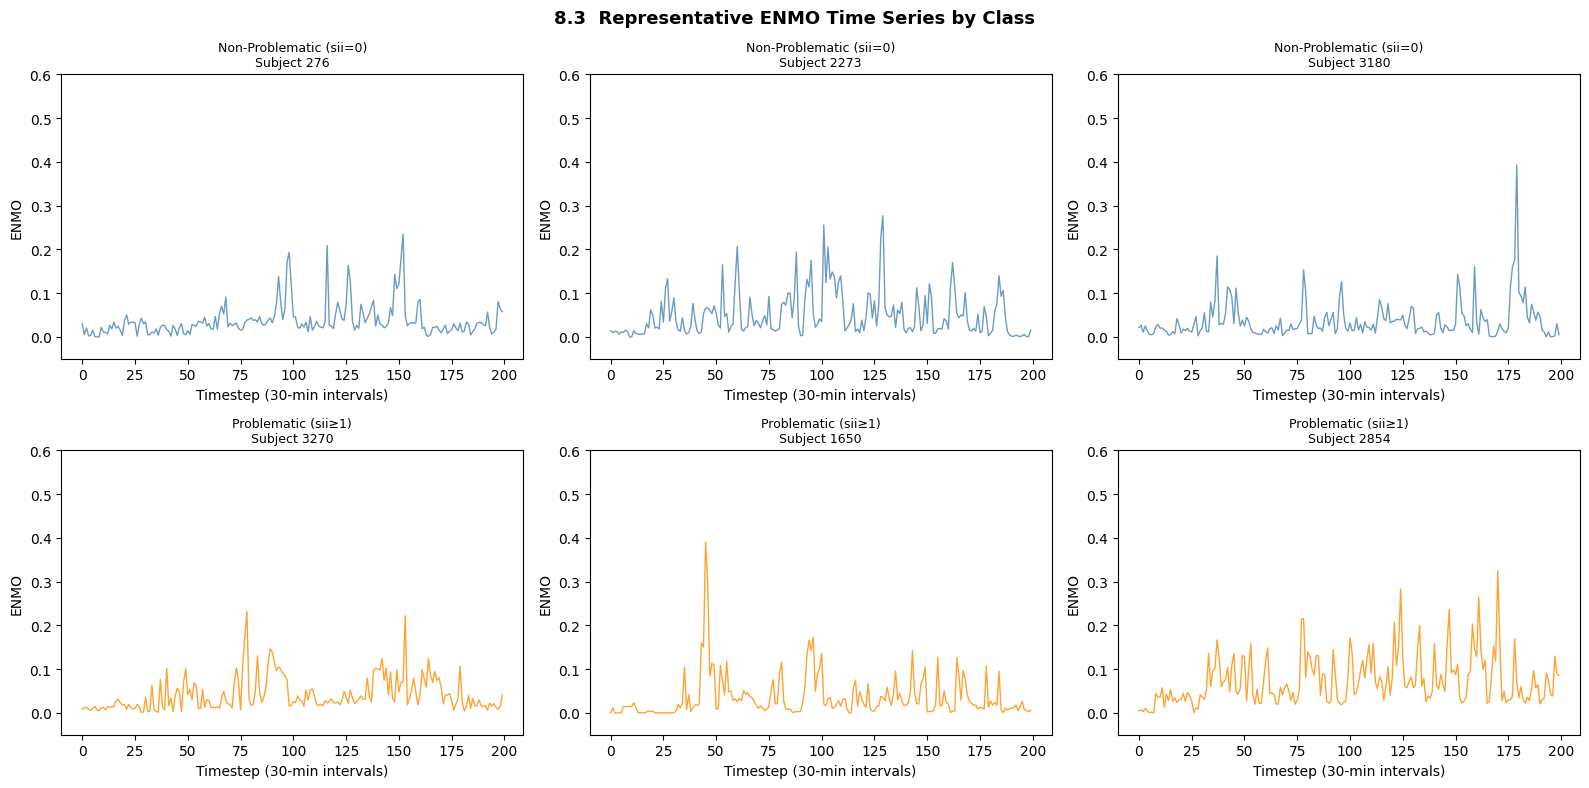

In [ ]:
# 8.3 REPRESENTATIVE ENMO SERIES PER CLASS


class_names = {0: 'Non-Problematic (sii=0)', 1: 'Problematic (sii≥1)'}
colors      = {0: 'steelblue', 1: 'darkorange'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for cls in [0, 1]:
    cls_indices = [i for i, d in enumerate(train_data)
                   if d['sii_binary'].iloc[0] == cls]
    samples = np.random.RandomState(42).choice(cls_indices, 3, replace=False)
    for j, idx in enumerate(samples):
        axes[cls][j].plot(train_data[idx]['enmo'].values,
                          color=colors[cls], alpha=0.8, linewidth=1)
        axes[cls][j].set_title(
            f"{class_names[cls]}\nSubject {train_data[idx]['id'].iloc[0]}",
            fontsize=9)
        axes[cls][j].set_xlabel("Timestep (30-min intervals)")
        axes[cls][j].set_ylabel("ENMO")
        axes[cls][j].set_ylim(-0.05, 0.6)

plt.suptitle("8.3  Representative ENMO Time Series by Class",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

8.3.1 Global Distributions

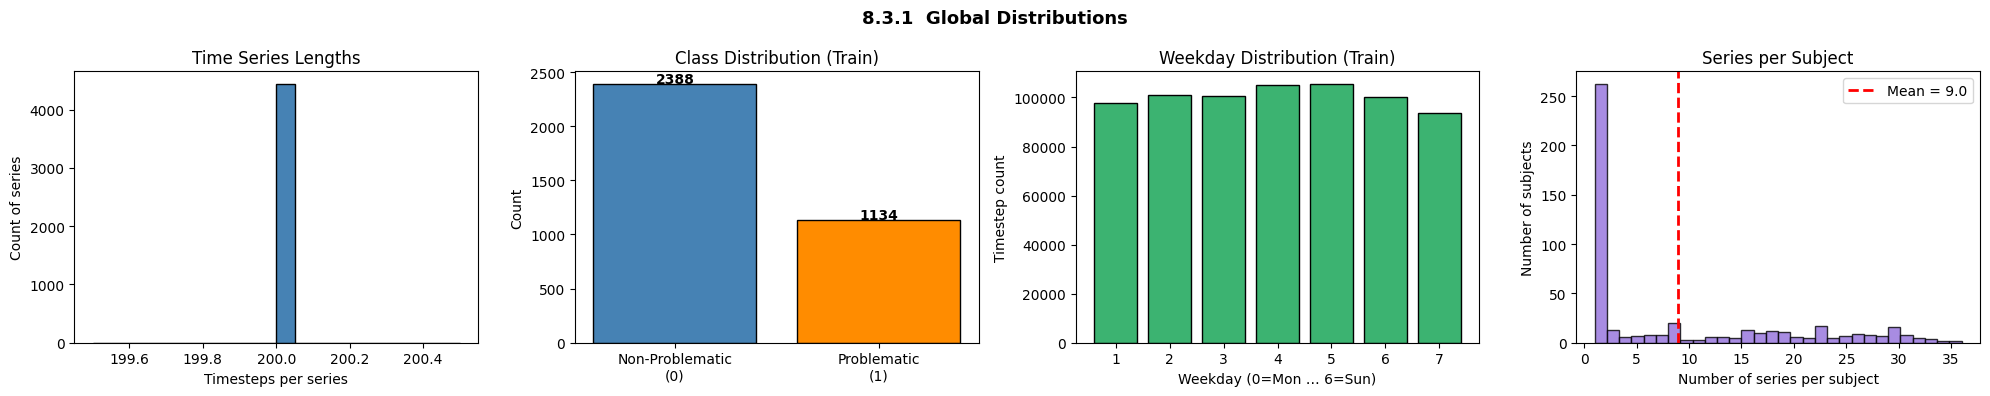

Class distribution (train):
  Non-Problematic (0): 2388  (67.8%)
  Problematic     (1): 1134  (32.2%)

Series per subject:
  Min:    1
  Max:    36
  Mean:   9.0
  Median: 2.0


In [ ]:
# 8.3.1 GLOBAL DISTRIBUTIONS


series_per_subject = Counter(subject_ids)
sps_vals = list(series_per_subject.values())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Series lengths
lengths = [len(df) for df in CMI_timeseries_dataset]
axes[0].hist(lengths, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Time Series Lengths")
axes[0].set_xlabel("Timesteps per series")
axes[0].set_ylabel("Count of series")

#  Class distribution (train)
counts = [(y_train==0).sum(), (y_train==1).sum()]
bars = axes[1].bar(['Non-Problematic\n(0)', 'Problematic\n(1)'],
                    counts, color=['steelblue','darkorange'], edgecolor='black')
axes[1].set_title("Class Distribution (Train)")
axes[1].set_ylabel("Count")
for bar, v in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 10,
                 str(v), ha='center', fontweight='bold')

#   Weekday distribution (our categorical metadata equivalent)
all_weekdays = np.concatenate([df['weekday'].values for df in train_data])
wd_counts = Counter(all_weekdays)
wd_labels = sorted(wd_counts.keys())
axes[2].bar([str(int(w)) for w in wd_labels],
            [wd_counts[w] for w in wd_labels],
            color='mediumseagreen', edgecolor='black')
axes[2].set_title("Weekday Distribution (Train)")
axes[2].set_xlabel("Weekday (0=Mon … 6=Sun)")
axes[2].set_ylabel("Timestep count")

# Series-per-subject distribution
axes[3].hist(sps_vals, bins=30, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[3].axvline(np.mean(sps_vals), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(sps_vals):.1f}')
axes[3].set_title("Series per Subject")
axes[3].set_xlabel("Number of series per subject")
axes[3].set_ylabel("Number of subjects")
axes[3].legend()

plt.suptitle("8.3.1  Global Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print("Class distribution (train):")
print(f"  Non-Problematic (0): {counts[0]}  ({counts[0]/sum(counts)*100:.1f}%)")
print(f"  Problematic     (1): {counts[1]}  ({counts[1]/sum(counts)*100:.1f}%)")
print()
print("Series per subject:")
print(f"  Min:    {min(sps_vals)}")
print(f"  Max:    {max(sps_vals)}")
print(f"  Mean:   {np.mean(sps_vals):.1f}")
print(f"  Median: {np.median(sps_vals):.1f}")

 Missing Value and Zero Entry Analysis

Missing values — train: 0
Missing values — test:  0

Zero entries per feature (train set):
  X                        :       0 / 704400  (0.00%)
  Y                        :       0 / 704400  (0.00%)
  Z                        :       0 / 704400  (0.00%)
  enmo                     :   11220 / 704400  (1.59%)
  anglez                   :       0 / 704400  (0.00%)
  non-wear_flag            :  683927 / 704400  (97.09%)
  light                    :    3594 / 704400  (0.51%)
  battery_voltage          :       0 / 704400  (0.00%)

Non-wear flag analysis:
  Train — series with any non-wear:   144
  Train — series with >50% non-wear:  105
  Test  — series with any non-wear:   35
  Test  — series with >50% non-wear:  22

Flat ENMO series (std=0) — train: 2
Flat ENMO series (std=0) — test:  0


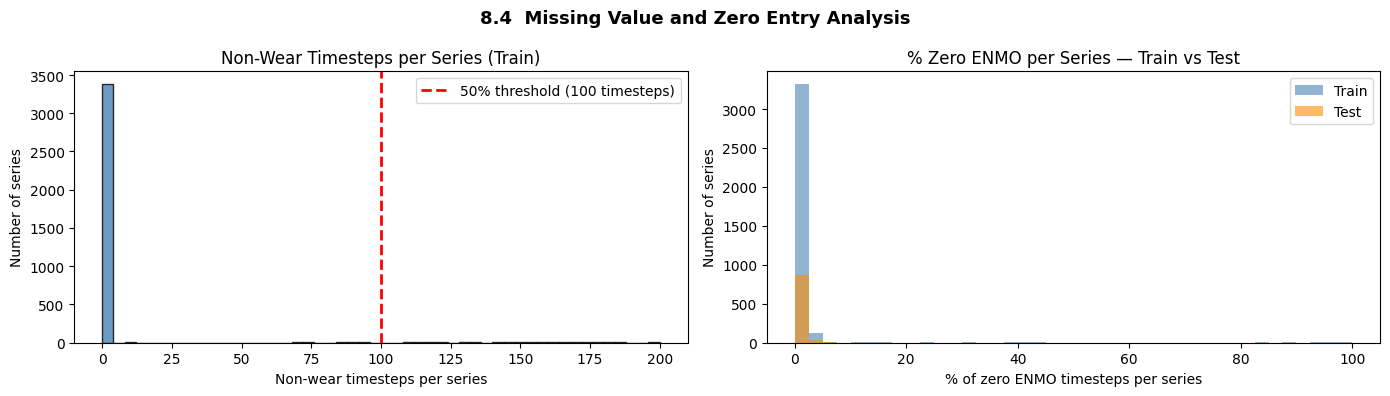

In [ ]:
# 8.4 MISSING VALUE AND ZERO ENTRY ANALYSIS

train_missing = sum(df.isnull().sum().sum() for df in train_data)
test_missing  = sum(df.isnull().sum().sum() for df in test_data)
print(f"Missing values — train: {train_missing}")
print(f"Missing values — test:  {test_missing}")
print()

# Zero entries per feature (train)
total_vals = sum(len(df) for df in train_data)
print("Zero entries per feature (train set):")
for col in ['X','Y','Z','enmo','anglez','non-wear_flag','light','battery_voltage']:
    zc = sum((df[col]==0).sum() for df in train_data)
    print(f"  {col:25s}: {zc:7d} / {total_vals}  ({zc/total_vals*100:.2f}%)")
print()

# Non-wear flag
nw_train = [(df['non-wear_flag']==1).sum() for df in train_data]
nw_test  = [(df['non-wear_flag']==1).sum() for df in test_data]
print("Non-wear flag analysis:")
print(f"  Train — series with any non-wear:   {sum(1 for x in nw_train if x > 0)}")
print(f"  Train — series with >50% non-wear:  {sum(1 for x in nw_train if x > 100)}")
print(f"  Test  — series with any non-wear:   {sum(1 for x in nw_test  if x > 0)}")
print(f"  Test  — series with >50% non-wear:  {sum(1 for x in nw_test  if x > 100)}")
print()

# Flat ENMO
flat_train = sum(1 for df in train_data if df['enmo'].std()==0)
flat_test  = sum(1 for df in test_data  if df['enmo'].std()==0)
print(f"Flat ENMO series (std=0) — train: {flat_train}")
print(f"Flat ENMO series (std=0) — test:  {flat_test}")

# ──  equivalent: % zeros per series — Train vs Test overlaid ─
zero_pct_train = [(df['enmo']==0).mean()*100 for df in train_data]
zero_pct_test  = [(df['enmo']==0).mean()*100 for df in test_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1 — Non-wear timesteps per series (train)
axes[0].hist(nw_train, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=2,
                label='50% threshold (100 timesteps)')
axes[0].set_title("Non-Wear Timesteps per Series (Train)")
axes[0].set_xlabel("Non-wear timesteps per series")
axes[0].set_ylabel("Number of series")
axes[0].legend()

# Plot 2 — % zero ENMO per series: Train vs Test overlaid (Fig 32)
axes[1].hist(zero_pct_train, bins=40, color='steelblue', alpha=0.6,
             label='Train', edgecolor='none')
axes[1].hist(zero_pct_test,  bins=40, color='darkorange', alpha=0.6,
             label='Test',  edgecolor='none')
axes[1].set_title("% Zero ENMO per Series — Train vs Test")
axes[1].set_xlabel("% of zero ENMO timesteps per series")
axes[1].set_ylabel("Number of series")
axes[1].legend()

plt.suptitle("8.4  Missing Value and Zero Entry Analysis",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

8.5 Outlier Detection and Treatment

In [ ]:
# ── 8.5 CLEANING PIPELINE ─────────────────────────────────────────────
# Step 1: Mask non-wear timesteps → NaN (physical signals untrustworthy)
# Step 2: Interpolate short gaps (≤5 steps = 2.5h), ffill/bfill long gaps
# Step 3: Drop fully non-worn series (non-wear_flag == 1 for ALL timesteps)
# Step 4: Drop series still >50% non-wear after interpolation
# Step 5: Drop flat ENMO series (std == 0)

PHYS_SIGNALS    = ['X', 'Y', 'Z', 'enmo', 'anglez']
NON_WEAR_THRESH = 0.5    # proportion within a 30-min window
INTERP_GAP_LIMIT = 5    # max consecutive NaN steps to interpolate linearly
LOW_BATTERY_MV   = 3200  # mV — below this = unreliable sensor

# ── Step 1: Mask non-wear timesteps to NaN ────────────────────────────
def mask_nonwear(df, threshold=NON_WEAR_THRESH):
    """Set physical signals to NaN where sensor was off the wrist."""
    df = df.copy()
    bad = df['non-wear_flag'] > threshold
    df.loc[bad, PHYS_SIGNALS] = np.nan
    return df

# ── Step 2: Gap-limited interpolation ────────────────────────────────
def interpolate_gaps(df, cols=PHYS_SIGNALS, max_gap=INTERP_GAP_LIMIT):
    """
    Linear interpolation for short gaps (≤ max_gap consecutive NaN steps).
    Forward/backward fill for longer gaps — avoids fabricating long trends.
    """
    df = df.copy()
    for col in cols:
        s       = df[col].copy()
        is_nan  = s.isna()
        if not is_nan.any():
            continue
        # Label each consecutive run
        grp      = (is_nan != is_nan.shift()).cumsum()
        gap_size = is_nan.groupby(grp).transform('sum')
        # Linearly interpolate only short gaps
        s_interp = s.interpolate(method='linear')
        s[is_nan & (gap_size <= max_gap)] = s_interp[is_nan & (gap_size <= max_gap)]
        # Forward/backward fill remaining long gaps
        s        = s.ffill().bfill()
        df[col]  = s
    return df

# ── Apply Steps 1 & 2 to all data ────────────────────────────────────
def clean_series(data):
    cleaned = []
    for df in data:
        df_masked = mask_nonwear(df)
        df_clean  = interpolate_gaps(df_masked)
        cleaned.append(df_clean)
    return cleaned

train_cleaned_raw = clean_series(train_data)
test_cleaned_raw  = clean_series(test_data)

# Sanity check — no NaNs should remain
train_nans = sum(df[PHYS_SIGNALS].isna().sum().sum()
                 for df in train_cleaned_raw)
test_nans  = sum(df[PHYS_SIGNALS].isna().sum().sum()
                 for df in test_cleaned_raw)
print(f"Remaining NaNs after interpolation — train: {train_nans}  test: {test_nans}")
print(f"(both must be 0) ✓" if train_nans == 0 and test_nans == 0 else "⚠ NaNs remain!")
print()

# ── Step 3 & 4 & 5: Filter series ────────────────────────────────────
def filter_series(data):
    kept              = []
    dropped_full_nw   = 0   # non-wear_flag == 1 for ALL 200 timesteps
    dropped_excess_nw = 0   # still >50% non-wear after interpolation
    dropped_flat      = 0   # enmo std == 0 after cleaning

    for df in data:
        # Step 3: drop fully non-worn
        if (df['non-wear_flag'] == 1).all():
            dropped_full_nw += 1
            continue
        # Step 4: drop >50% non-wear
        nw_ratio = (df['non-wear_flag'] > NON_WEAR_THRESH).mean()
        if nw_ratio > 0.5:
            dropped_excess_nw += 1
            continue
        # Step 5: drop flat ENMO
        if df['enmo'].std() == 0:
            dropped_flat += 1
            continue
        kept.append(df)

    return kept, dropped_full_nw, dropped_excess_nw, dropped_flat

(train_clean,
 tr_full_nw, tr_excess_nw, tr_flat) = filter_series(train_cleaned_raw)

(test_clean,
 te_full_nw, te_excess_nw, te_flat)  = filter_series(test_cleaned_raw)

y_train_clean      = np.array([df['sii_binary'].iloc[0] for df in train_clean])
y_test_clean       = np.array([df['sii_binary'].iloc[0] for df in test_clean])
groups_train_clean = np.array([df['id'].iloc[0] for df in train_clean])
groups_test_clean  = np.array([df['id'].iloc[0] for df in test_clean])

# ── Add quality flag: low battery ────────────────────────────────────
train_low_batt = sum(1 for df in train_clean
                     if (df['battery_voltage'] < LOW_BATTERY_MV).any())
test_low_batt  = sum(1 for df in test_clean
                     if (df['battery_voltage'] < LOW_BATTERY_MV).any())

print("TRAIN:")
print(f"  Original series:              {len(train_data)}")
print(f"  Dropped (fully non-worn):     {tr_full_nw}")
print(f"  Dropped (>50% non-wear):      {tr_excess_nw}")
print(f"  Dropped (flat ENMO):          {tr_flat}")
print(f"  Kept series:                  {len(train_clean)}")
print(f"  Unique subjects retained:     {len(np.unique(groups_train_clean))}")
print(f"  Series with low battery:      {train_low_batt}")
print()
print("TEST:")
print(f"  Original series:              {len(test_data)}")
print(f"  Dropped (fully non-worn):     {te_full_nw}")
print(f"  Dropped (>50% non-wear):      {te_excess_nw}")
print(f"  Dropped (flat ENMO):          {te_flat}")
print(f"  Kept series:                  {len(test_clean)}")
print(f"  Unique subjects retained:     {len(np.unique(groups_test_clean))}")
print(f"  Series with low battery:      {test_low_batt}")
print()
print("Class distribution after cleaning:")
print(f"  Train — Non-problematic (0): {(y_train_clean==0).sum()}  "
      f"({(y_train_clean==0).mean()*100:.1f}%)")
print(f"  Train — Problematic     (1): {(y_train_clean==1).sum()}  "
      f"({(y_train_clean==1).mean()*100:.1f}%)")
print(f"  Test  — Non-problematic (0): {(y_test_clean==0).sum()}   "
      f"({(y_test_clean==0).mean()*100:.1f}%)")
print(f"  Test  — Problematic     (1): {(y_test_clean==1).sum()}   "
      f"({(y_test_clean==1).mean()*100:.1f}%)")

In [ ]:
# ── 8.5 VISUALS ───────────────────────────────────────────────────────

# ── Fig 1: Example of masking + interpolation on one series ──────────
# Find a series that had some non-wear timesteps
example_raw  = next(df for df in train_data
                    if 0 < (df['non-wear_flag'] == 1).sum() < 50)
example_idx  = train_data.index(example_raw) if hasattr(train_data, 'index') else \
               next(i for i, df in enumerate(train_data)
                    if df is example_raw)

example_clean = train_cleaned_raw[example_idx]
nw_mask       = example_raw['non-wear_flag'] > NON_WEAR_THRESH

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Raw signal with non-wear regions highlighted
axes[0].plot(example_raw['enmo'].values, color='steelblue',
             linewidth=0.9, label='Original ENMO')
for pos in np.where(nw_mask)[0]:
    axes[0].axvspan(pos - 0.5, pos + 0.5,
                    alpha=0.3, color='red')
axes[0].plot([], [], color='red', alpha=0.5,
             lw=8, label='Non-wear timestep (masked → NaN)')
axes[0].set_title("Before: Original ENMO with non-wear regions highlighted")
axes[0].set_ylabel("ENMO")
axes[0].legend(fontsize=8)

# After interpolation
axes[1].plot(example_clean['enmo'].values, color='mediumseagreen',
             linewidth=0.9, label='ENMO after interpolation')
for pos in np.where(nw_mask)[0]:
    axes[1].axvspan(pos - 0.5, pos + 0.5,
                    alpha=0.15, color='darkorange')
axes[1].plot([], [], color='darkorange', alpha=0.5,
             lw=8, label='Interpolated region')
axes[1].set_title("After: ENMO after masking + gap-limited interpolation")
axes[1].set_xlabel("Timestep (30-min intervals)")
axes[1].set_ylabel("ENMO")
axes[1].legend(fontsize=8)

plt.suptitle("8.5  Masking + Interpolation — Before vs After",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Fig 2: Kept vs Dropped series ────────────────────────────────────
dropped_series = [df for df in train_data
                  if (df['non-wear_flag'] > NON_WEAR_THRESH).mean() > 0.5]
if dropped_series:
    high_nw = dropped_series[0]
    kept    = train_clean[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(kept['enmo'].values, color='steelblue',
                 linewidth=1, alpha=0.8,
                 label=f"Kept  (non-wear frac="
                       f"{(kept['non-wear_flag']>NON_WEAR_THRESH).mean():.2f})")
    axes[0].plot(high_nw['enmo'].values, color='red',
                 linewidth=1, alpha=0.8,
                 label=f"Dropped (non-wear frac="
                       f"{(high_nw['non-wear_flag']>NON_WEAR_THRESH).mean():.2f})")
    axes[0].set_title("Example: Kept vs Dropped Series")
    axes[0].set_xlabel("Timestep (30-min intervals)")
    axes[0].set_ylabel("ENMO")
    axes[0].legend(fontsize=8)

    # Before vs After bar chart
    categories = ['Original', 'Kept', 'Dropped\n(fully non-worn)',
                  'Dropped\n(>50% non-wear)', 'Dropped\n(flat ENMO)']
    values     = [len(train_data), len(train_clean),
                  tr_full_nw, tr_excess_nw, tr_flat]
    colors     = ['steelblue', 'green', 'red', 'darkorange', 'grey']
    bars = axes[1].bar(categories, values, color=colors, edgecolor='black')
    axes[1].set_title("Train Set — Cleaning Pipeline Summary")
    axes[1].set_ylabel("Number of Series")
    for bar, v in zip(bars, values):
        if v > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, v + 5,
                         str(v), ha='center', fontweight='bold', fontsize=9)

    plt.suptitle("8.5  Outlier Detection and Treatment",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Fig 3: Class distribution before vs after ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y, title in [
    (axes[0], np.array([df['sii_binary'].iloc[0] for df in train_data]),
     "Before Cleaning"),
    (axes[1], y_train_clean, "After Cleaning")
]:
    vals = [(y==0).sum(), (y==1).sum()]
    bars = ax.bar(['Non-Problematic', 'Problematic'],
                  vals, color=['steelblue', 'darkorange'], edgecolor='black')
    ax.set_title(f"Train Class Distribution — {title}")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10,
                str(v), ha='center', fontweight='bold')

plt.suptitle("Class Distribution Before vs After Cleaning",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

 Normalization and Signal-Shaping Transformations

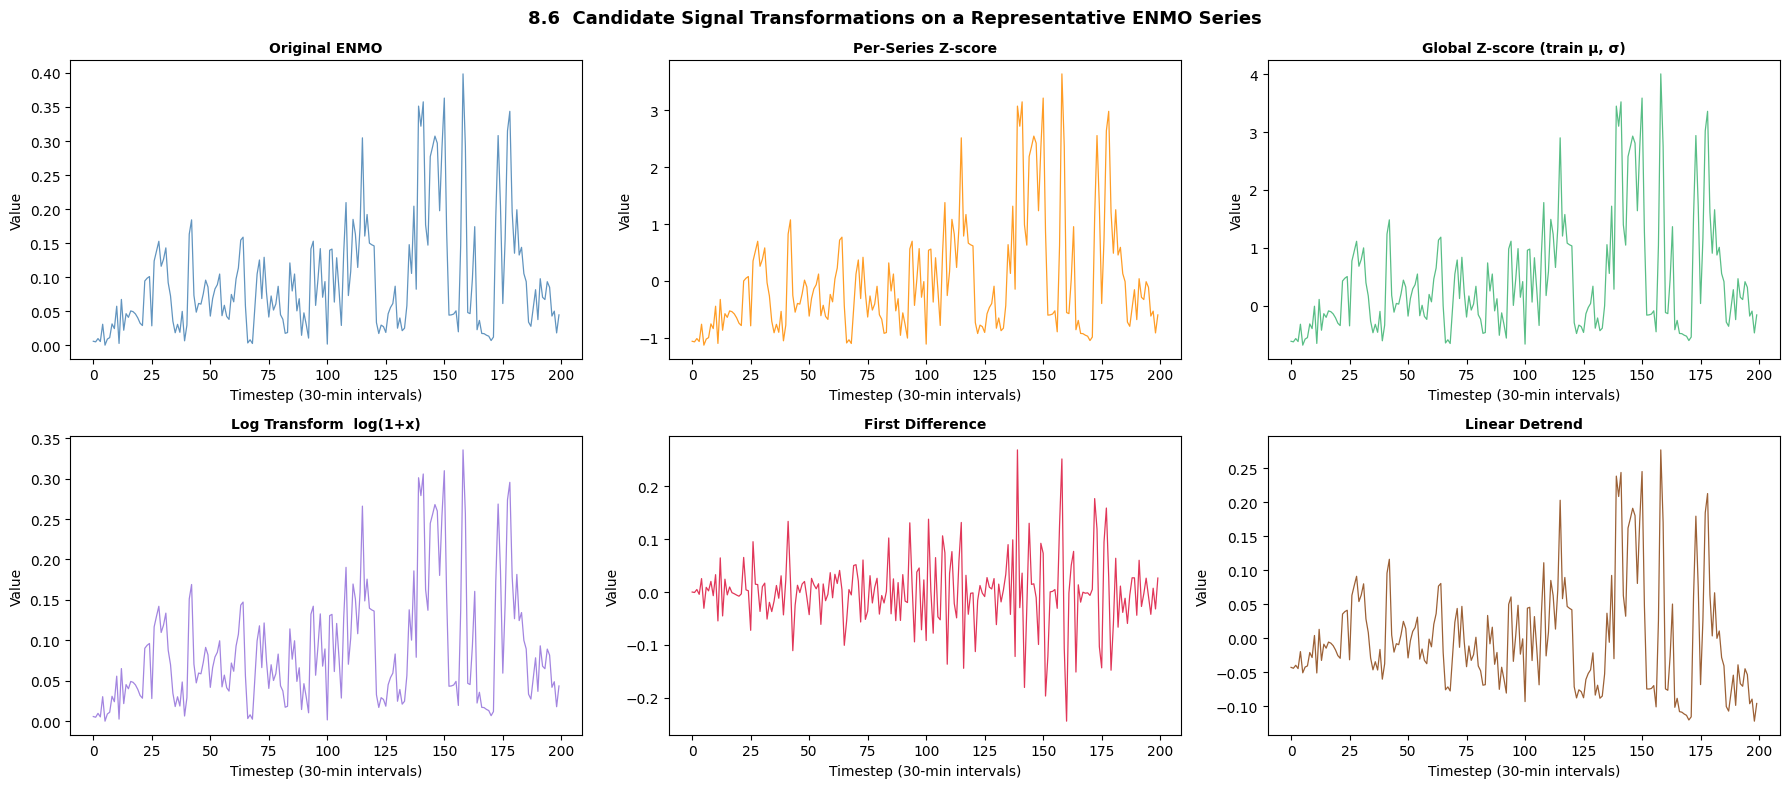

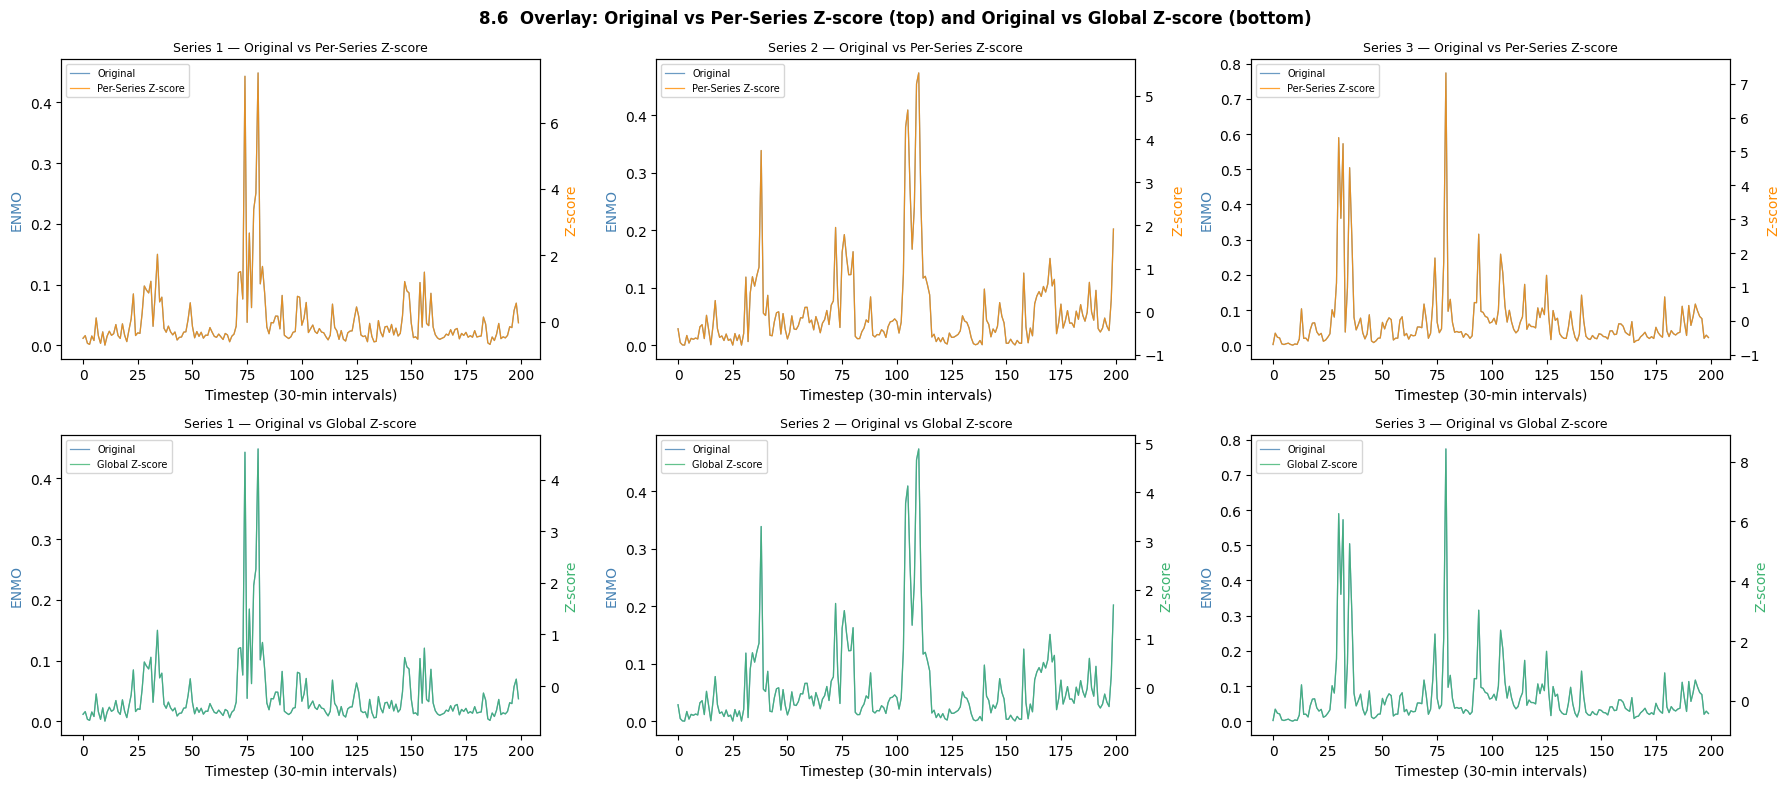

✓ Normalization complete.

  X_train_enmo  shape : (3417, 200)   ← KNN & Shapelets
  X_test_enmo   shape : (893, 200)
  X_train_multi shape : (3417, 200, 11)  ← ROCKET
  X_test_multi  shape : (893, 200, 11)

  Global ENMO mean (train_clean): 0.05822
  Global ENMO std  (train_clean): 0.08492

  Per-series Z-score → shape and activity pattern preserved per subject
  StandardScaler     → all 11 features on same scale for ROCKET
  Global Z-score     → used for PAA, SAX, and statistical features


In [ ]:
# 8.6 NORMALIZATION AND SIGNAL-SHAPING TRANSFORMATIONS

# 8.6 NORMALIZATION AND SIGNAL-SHAPING TRANSFORMATIONS
# Global stats computed on CLEANED train data only (no leakage)
all_train_enmo = np.concatenate([df['enmo'].values for df in train_clean])
global_mean    = all_train_enmo.mean()
global_std     = all_train_enmo.std()

# Representative series for visualization
rng       = np.random.RandomState(0)
cands     = [df for df in train_clean if df['enmo'].std() > 0.05]
rep_df    = cands[rng.randint(0, len(cands))]
enmo_orig = rep_df['enmo'].values.astype(np.float64)
t         = np.arange(len(enmo_orig))

# Per-series Z-score helper
def zscore_per_series(series):
    mu, sigma = series.mean(), series.std()
    if sigma < 1e-8:
        return np.zeros_like(series)
    return (series - mu) / sigma

#  Six candidate transforms
trans = {
    'Original ENMO':               enmo_orig,
    'Per-Series Z-score':          zscore_per_series(enmo_orig),
    'Global Z-score (train μ, σ)': (enmo_orig - global_mean) / global_std,
    'Log Transform  log(1+x)':     np.log1p(enmo_orig),
    'First Difference':            np.diff(enmo_orig, prepend=enmo_orig[0]),
    'Linear Detrend':              enmo_orig - np.polyval(
                                       np.polyfit(t, enmo_orig, 1), t),
}
colors_t = ['steelblue','darkorange','mediumseagreen',
            'mediumpurple','crimson','saddlebrown']

# ──  6-panel candidate transformations ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for ax, (name, vals), col in zip(axes, trans.items(), colors_t):
    ax.plot(t, vals, color=col, linewidth=0.9, alpha=0.85)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Timestep (30-min intervals)")
    ax.set_ylabel("Value")

plt.suptitle(
    "8.6  Candidate Signal Transformations on a Representative ENMO Series",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Row 0: Original vs Per-Series Z-score (3 examples)
# Row 1: Original vs Global Z-score (same 3 examples)
rng2  = np.random.RandomState(7)
picks = rng2.choice(len(cands), 3, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for j, idx in enumerate(picks):
    enmo = cands[idx]['enmo'].values.astype(np.float64)
    t2   = np.arange(len(enmo))
    zs   = zscore_per_series(enmo)
    zg   = (enmo - global_mean) / global_std

    # Row 0 — Per-Series Z-score
    ax  = axes[0][j]
    ax2 = ax.twinx()
    ax.plot(t2, enmo, color='steelblue',  linewidth=0.9,
            alpha=0.8, label='Original')
    ax2.plot(t2, zs,  color='darkorange', linewidth=0.9,
             alpha=0.8, label='Per-Series Z-score')
    ax.set_title(f"Series {j+1} — Original vs Per-Series Z-score", fontsize=9)
    ax.set_xlabel("Timestep (30-min intervals)")
    ax.set_ylabel("ENMO", color='steelblue')
    ax2.set_ylabel("Z-score", color='darkorange')
    l1, n1 = ax.get_legend_handles_labels()
    l2, n2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, n1+n2, fontsize=7, loc='upper left')

    # Row 1 — Global Z-score
    ax  = axes[1][j]
    ax2 = ax.twinx()
    ax.plot(t2, enmo, color='steelblue',      linewidth=0.9,
            alpha=0.8, label='Original')
    ax2.plot(t2, zg,  color='mediumseagreen', linewidth=0.9,
             alpha=0.8, label='Global Z-score')
    ax.set_title(f"Series {j+1} — Original vs Global Z-score", fontsize=9)
    ax.set_xlabel("Timestep (30-min intervals)")
    ax.set_ylabel("ENMO", color='steelblue')
    ax2.set_ylabel("Z-score", color='mediumseagreen')
    l1, n1 = ax.get_legend_handles_labels()
    l2, n2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, n1+n2, fontsize=7, loc='upper left')

plt.suptitle(
    "8.6  Overlay: Original vs Per-Series Z-score (top) "
    "and Original vs Global Z-score (bottom)",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Build the actual arrays for classification

# 1) Per-series Z-score on ENMO → KNN and Shapelets (univariate)
X_train_enmo = np.array([zscore_per_series(df['enmo'].values)
                          for df in train_clean])   # (3417, 200)
X_test_enmo  = np.array([zscore_per_series(df['enmo'].values)
                          for df in test_clean])    # (893,  200)

# 2) StandardScaler on ALL features → ROCKET (multivariate)
ALL_FEATURES = ['X','Y','Z','enmo','anglez','non-wear_flag',
                'light','battery_voltage','weekday','quarter',
                'relative_date_PCIAT']
T = 200  # timesteps

train_flat        = np.vstack([df[ALL_FEATURES].values for df in train_clean])
test_flat         = np.vstack([df[ALL_FEATURES].values for df in test_clean])
scaler            = StandardScaler()
train_flat_scaled = scaler.fit_transform(train_flat)   # fit on train only
test_flat_scaled  = scaler.transform(test_flat)

X_train_multi = train_flat_scaled.reshape(len(train_clean), T, len(ALL_FEATURES))
X_test_multi  = test_flat_scaled.reshape(len(test_clean),  T, len(ALL_FEATURES))

# 3) Global Z-score on ENMO → for PAA/SAX and statistical features
train_normalized = []
for df in train_clean:
    df_n = df.copy()
    df_n['enmo_norm'] = (df['enmo'].values - global_mean) / global_std
    train_normalized.append(df_n)

test_normalized = []
for df in test_clean:
    df_n = df.copy()
    df_n['enmo_norm'] = (df['enmo'].values - global_mean) / global_std
    test_normalized.append(df_n)

print("✓ Normalization complete.")
print()
print(f"  X_train_enmo  shape : {X_train_enmo.shape}   ← KNN & Shapelets")
print(f"  X_test_enmo   shape : {X_test_enmo.shape}")
print(f"  X_train_multi shape : {X_train_multi.shape}  ← ROCKET")
print(f"  X_test_multi  shape : {X_test_multi.shape}")
print()
print(f"  Global ENMO mean (train_clean): {global_mean:.5f}")
print(f"  Global ENMO std  (train_clean): {global_std:.5f}")
print()
print("  Per-series Z-score → shape and activity pattern preserved per subject")
print("  StandardScaler     → all 11 features on same scale for ROCKET")
print("  Global Z-score     → used for PAA, SAX, and statistical features")

For EACH series individually, subtract its own mean and divide by its own standard deviation.

Uses the SAME mean and standard deviation calculated from ALL training data to normalize every series.



Reduces the length of a time series by averaging segments, Converts a continuous time series into a string of letters

Statistical Feature Extraction (Z-Normalized Signals)

Statistical Feature Extraction Complete
  Training features shape: (3417, 17)
  Test     features shape: (893, 17)

Feature names: ['max_activity', 'peak_to_peak', 'mad_activity', 'iqr_activity', 'rolling_std_mean', 'skewness', 'kurtosis', 'first_week_sum', 'first_week_max', 'slope_first_7', 'peak_time', 'growth_to_peak', 'pct_nonzero', 'non_wear_ratio', 'enmo_diff_mean', 'enmo_diff_std']

Feature Statistics (Training Set):
       max_activity  peak_to_peak  mad_activity  iqr_activity  \
count     3417.0000     3417.0000     3417.0000     3417.0000   
mean         5.6127        6.5027        0.6722        0.8253   
std          1.4938        1.4056        0.0812        0.2663   
min          0.7929        2.5735        0.1781        0.0030   
25%          4.5543        5.4970        0.6232        0.6346   
50%          5.4012        6.2833        0.6805        0.8113   
75%          6.4034        7.2221        0.7306        1.0086   
max         14.0548       14.1746        0.9624     

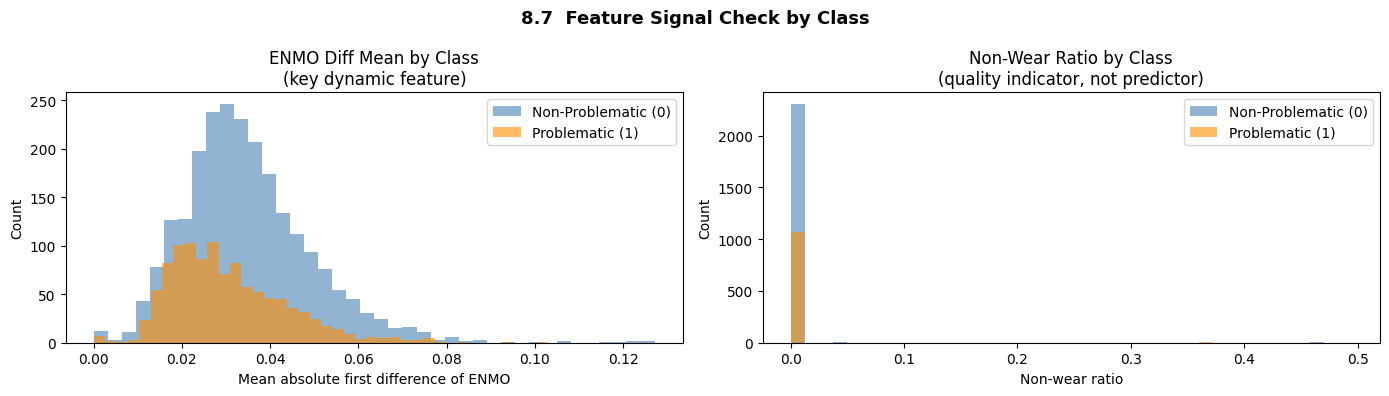

In [ ]:
# ── 8.7 STATISTICAL FEATURE EXTRACTION (Z-NORMALIZED SIGNALS) ────────

def extract_statistical_features(series):
    features = {}

    # Magnitude (total_activity and std_activity removed —
    # constant by construction of per-series Z-score:
    # mean=0 always → sum≈0, std=1 always → no information)
    features['max_activity']     = np.max(series)
    features['peak_to_peak']     = np.max(series) - np.min(series)

    # Dispersion
    features['mad_activity']     = np.mean(np.abs(series - np.mean(series)))
    features['iqr_activity']     = np.percentile(series, 75) - np.percentile(series, 25)
    features['rolling_std_mean'] = np.mean([np.std(series[i:i+10])
                                            for i in range(0, len(series)-10, 10)])

    # Shape
    features['skewness']         = stats.skew(series)
    features['kurtosis']         = stats.kurtosis(series)

    # Early dynamics (first 7 timesteps = first ~3.5 hours)
    features['first_week_sum']   = np.sum(series[:7])
    features['first_week_max']   = np.max(series[:7])
    features['slope_first_7']    = np.polyfit(range(7), series[:7], 1)[0]

    # Peak analysis
    peak_idx                     = np.argmax(series)
    features['peak_time']        = peak_idx
    features['growth_to_peak']   = series[peak_idx] - series[0] if peak_idx > 0 else 0

    # Activity proportion
    features['pct_nonzero']      = np.mean(series > 0.01) * 100

    return features

# ── Extract features ──────────────────────────────────────────────────
train_features = []
for i, series in enumerate(X_train_enmo):
    f = extract_statistical_features(series)
    raw = train_clean[i]['enmo'].values
    f['non_wear_ratio'] = (train_clean[i]['non-wear_flag'] == 1).mean()
    f['enmo_diff_mean'] = np.mean(np.abs(np.diff(raw)))
    f['enmo_diff_std']  = np.std(np.diff(raw))
    train_features.append(f)

test_features = []
for i, series in enumerate(X_test_enmo):
    f = extract_statistical_features(series)
    raw = test_clean[i]['enmo'].values
    f['non_wear_ratio'] = (test_clean[i]['non-wear_flag'] == 1).mean()
    f['enmo_diff_mean'] = np.mean(np.abs(np.diff(raw)))
    f['enmo_diff_std']  = np.std(np.diff(raw))
    test_features.append(f)

train_features_df = pd.DataFrame(train_features)
test_features_df  = pd.DataFrame(test_features)

train_features_df['sii_binary'] = y_train_clean
test_features_df['sii_binary']  = y_test_clean

print("Statistical Feature Extraction Complete")
print(f"  Training features shape: {train_features_df.shape}")
print(f"  Test     features shape: {test_features_df.shape}")
print(f"\nFeature names: {list(train_features_df.columns[:-1])}")
print(f"\nFeature Statistics (Training Set):")
print(train_features_df.describe().round(4))

# ── Feature signal check by class ────────────────────────────────────
print("\nKey feature means by class:")
key_features = ['enmo_diff_mean', 'enmo_diff_std', 'mad_activity',
                'iqr_activity', 'skewness', 'kurtosis', 'non_wear_ratio']
signal_check = train_features_df.groupby('sii_binary')[key_features].agg(
    ['mean', 'std']).round(4)
print(signal_check)

# ── Non-wear threshold justification ─────────────────────────────────
all_nw = train_features_df['non_wear_ratio'].values
print("\nNon-wear ratio percentiles (train_clean, after filtering):")
for q in [0.50, 0.75, 0.90, 0.95]:
    print(f"  {int(q*100)}th: {np.quantile(all_nw, q):.4f}")
print(f"  Max: {all_nw.max():.4f}")
print("\n→ Median = 0: vast majority of kept series have zero non-wear.")
print("  Non-wear ratio NOT predictive of sii_binary (means nearly identical).")
print("  Role: data quality indicator for filtering, not a classifier feature.")

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# enmo_diff_mean by class
axes[0].hist(
    train_features_df[train_features_df['sii_binary']==0]['enmo_diff_mean'],
    bins=40, color='steelblue', alpha=0.6, label='Non-Problematic (0)')
axes[0].hist(
    train_features_df[train_features_df['sii_binary']==1]['enmo_diff_mean'],
    bins=40, color='darkorange', alpha=0.6, label='Problematic (1)')
axes[0].set_title("ENMO Diff Mean by Class\n(key dynamic feature)")
axes[0].set_xlabel("Mean absolute first difference of ENMO")
axes[0].set_ylabel("Count")
axes[0].legend()

# non_wear_ratio by class
axes[1].hist(
    train_features_df[train_features_df['sii_binary']==0]['non_wear_ratio'],
    bins=40, color='steelblue', alpha=0.6, label='Non-Problematic (0)')
axes[1].hist(
    train_features_df[train_features_df['sii_binary']==1]['non_wear_ratio'],
    bins=40, color='darkorange', alpha=0.6, label='Problematic (1)')
axes[1].set_title("Non-Wear Ratio by Class\n(quality indicator, not predictor)")
axes[1].set_xlabel("Non-wear ratio")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("8.7  Feature Signal Check by Class",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Time-Series Approximation: PAA and SAX

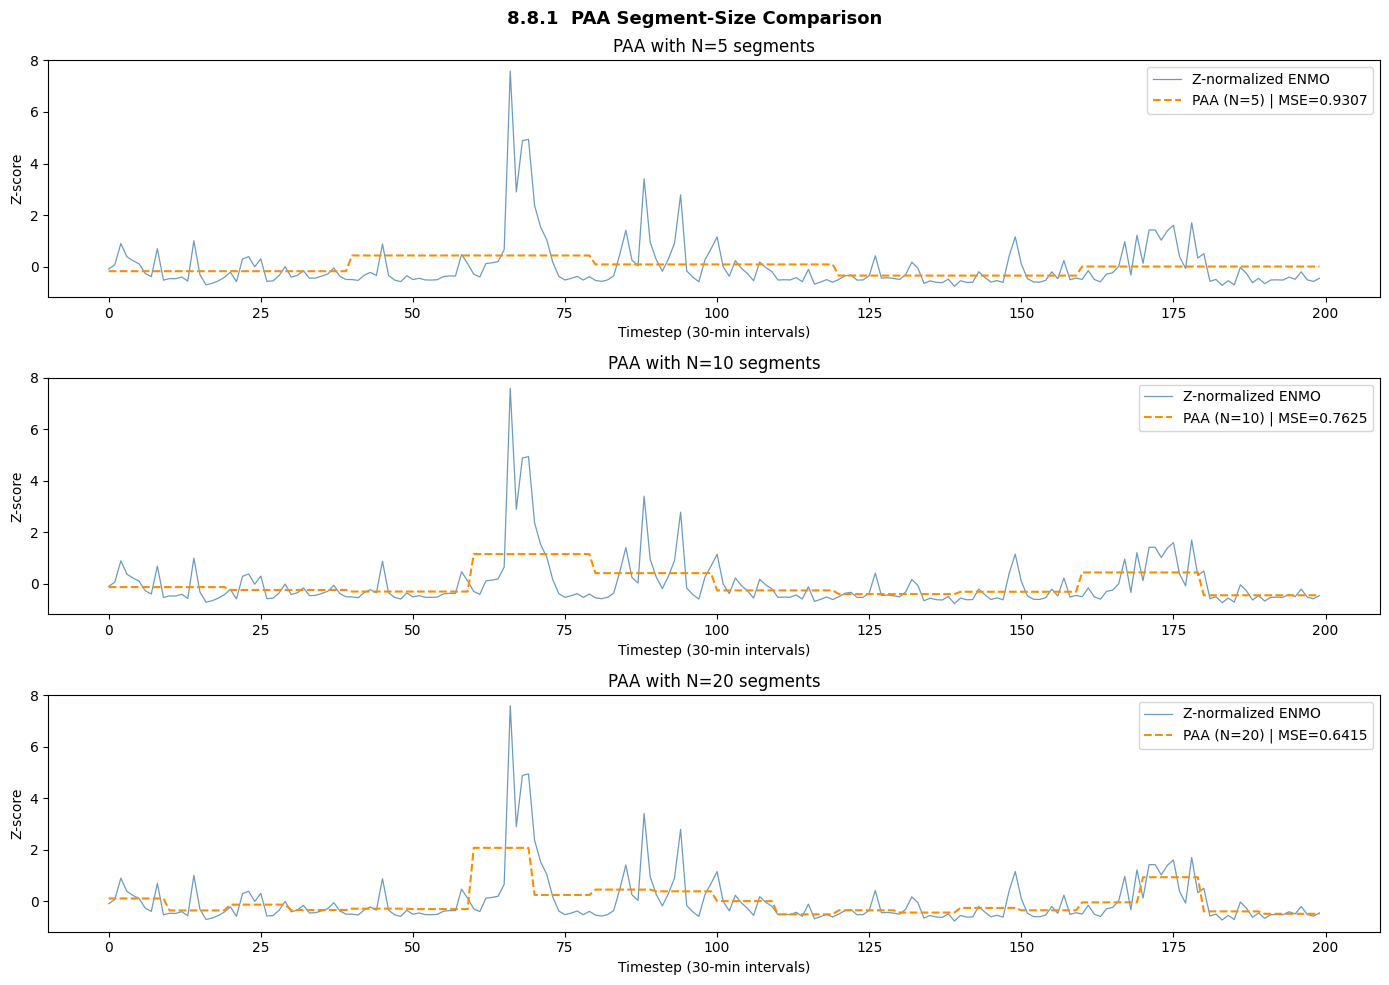

PAA MSE comparison:
  N= 5: MSE=0.9307
  N=10: MSE=0.7625
  N=20: MSE=0.6415

→ Selected N=20: lowest MSE, best balance of fidelity and compression


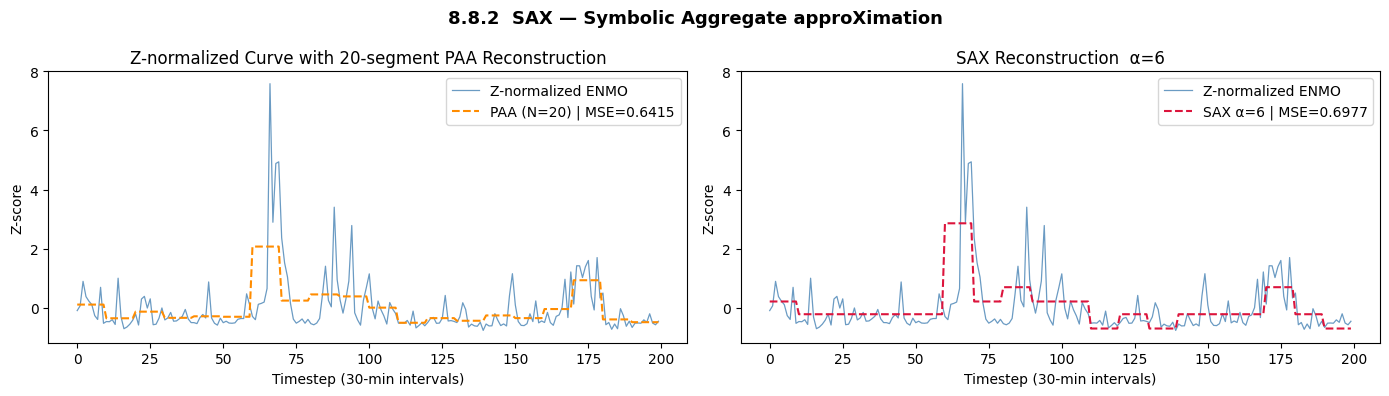

Alphabet size comparison (MSE on representative series):
  α=3: MSE=1.7487
  α=4: MSE=0.8398
  α=6: MSE=0.6977

→ Selected α=6: lowest MSE, best balance of expressiveness and noise robustness


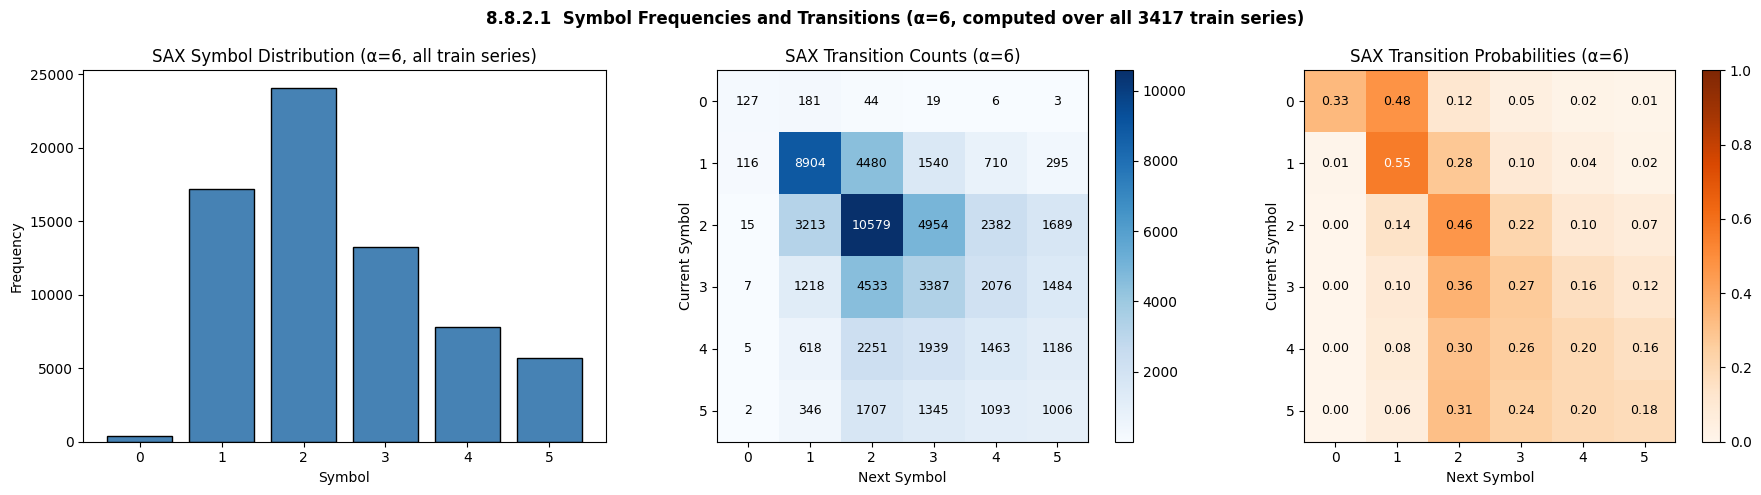


Total symbols analysed: 68,340 (= 3417 series × 20 segments)
Symbol frequencies:
  Symbol 0: 396  (0.6%)
  Symbol 1: 17,166  (25.1%)
  Symbol 2: 24,061  (35.2%)
  Symbol 3: 13,259  (19.4%)
  Symbol 4: 7,772  (11.4%)
  Symbol 5: 5,686  (8.3%)

Note: middle symbols dominate — expected for wrist accelerometry
where most timesteps are low/rest activity (right-skewed ENMO).
Transition matrix dominated by self-transitions → smooth temporal
evolution with low volatility ✓


In [ ]:
# 8.8 TIME-SERIES APPROXIMATION: PAA AND SAX

def piecewise_aggregate_approximation(series, num_segments):
    n        = len(series)
    seg_size = n / num_segments
    return np.array([series[int(i*seg_size):int((i+1)*seg_size)].mean()
                     for i in range(num_segments)])

def paa_reconstruct(paa_vals, original_length):
    seg_size = original_length // len(paa_vals)
    return np.repeat(paa_vals, seg_size)[:original_length]

def sax_encode(paa_series, alphabet_size):
    breakpoints = norm.ppf(np.linspace(0, 1, alphabet_size + 1)[1:-1])
    return np.digitize(paa_series, breakpoints)

def sax_region_midpoints(alpha):
    """Compute finite midpoints for each SAX symbol region."""
    midpoints = []
    for s in range(alpha):
        lo = norm.ppf(max(s / alpha,       1e-6))
        hi = norm.ppf(min((s + 1) / alpha, 1 - 1e-6))
        midpoints.append((lo + hi) / 2)
    return midpoints

# Representative series (per-series Z-scored)
rep_norm   = X_train_enmo[0]
seg_counts = [5, 10, 20]
mse_paa    = {}

# 8.8.1 PAA segment-size comparison
fig, axes = plt.subplots(len(seg_counts), 1, figsize=(14, 10))

for i, n_seg in enumerate(seg_counts):
    paa_vals = piecewise_aggregate_approximation(rep_norm, n_seg)
    recon    = paa_reconstruct(paa_vals, len(rep_norm))
    mse      = np.mean((rep_norm - recon)**2)
    mse_paa[n_seg] = mse

    axes[i].plot(rep_norm, color='steelblue', linewidth=0.9,
                 alpha=0.8, label='Z-normalized ENMO')
    axes[i].plot(recon, color='darkorange', linewidth=1.5,
                 linestyle='--',
                 label=f'PAA (N={n_seg}) | MSE={mse:.4f}')
    axes[i].set_title(f"PAA with N={n_seg} segments")
    axes[i].set_xlabel("Timestep (30-min intervals)")
    axes[i].set_ylabel("Z-score")
    axes[i].legend()

plt.suptitle("8.8.1  PAA Segment-Size Comparison",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("PAA MSE comparison:")
for n_seg, mse in mse_paa.items():
    print(f"  N={n_seg:2d}: MSE={mse:.4f}")
print(f"\n→ Selected N=20: lowest MSE, best balance of fidelity and compression")

# ── 8.8.2 SAX ─────────────────────────────────────────────────────────
N_SEGS  = 20
paa_rep = piecewise_aggregate_approximation(rep_norm, N_SEGS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#  Z-normalized curve with PAA reconstruction
paa_recon     = paa_reconstruct(paa_rep, len(rep_norm))
mse_paa_rep   = np.mean((rep_norm - paa_recon)**2)

axes[0].plot(rep_norm,  color='steelblue',  linewidth=0.9,
             alpha=0.8, label='Z-normalized ENMO')
axes[0].plot(paa_recon, color='darkorange', linewidth=1.5,
             linestyle='--',
             label=f'PAA (N=20) | MSE={mse_paa_rep:.4f}')
axes[0].set_title("Z-normalized Curve with 20-segment PAA Reconstruction")
axes[0].set_xlabel("Timestep (30-min intervals)")
axes[0].set_ylabel("Z-score")
axes[0].legend()

#  test α=3, 4, 6 — pick best by MSE
alpha_results = {}
for alpha in [3, 4, 6]:
    sax_sym  = sax_encode(paa_rep, alpha)
    rmeans   = sax_region_midpoints(alpha)
    sax_vals = np.array([rmeans[s] for s in sax_sym])
    sax_rec  = paa_reconstruct(sax_vals, len(rep_norm))
    mse      = np.mean((rep_norm - sax_rec)**2)
    alpha_results[alpha] = mse

best_alpha = min(alpha_results, key=alpha_results.get)

# Show α=best_alpha reconstruction
sax_sym_best  = sax_encode(paa_rep, best_alpha)
rmeans_best   = sax_region_midpoints(best_alpha)
sax_vals_best = np.array([rmeans_best[s] for s in sax_sym_best])
sax_rec_best  = paa_reconstruct(sax_vals_best, len(rep_norm))

axes[1].plot(rep_norm,     color='steelblue', linewidth=0.9,
             alpha=0.8, label='Z-normalized ENMO')
axes[1].plot(sax_rec_best, color='crimson',   linewidth=1.5,
             linestyle='--',
             label=f'SAX α={best_alpha} | MSE={alpha_results[best_alpha]:.4f}')
axes[1].set_title(f"SAX Reconstruction  α={best_alpha}")
axes[1].set_xlabel("Timestep (30-min intervals)")
axes[1].set_ylabel("Z-score")
axes[1].legend()

plt.suptitle("8.8.2  SAX — Symbolic Aggregate approXimation",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Alphabet size comparison (MSE on representative series):")
for alpha, mse in alpha_results.items():
    print(f"  α={alpha}: MSE={mse:.4f}")
print(f"\n→ Selected α={best_alpha}: lowest MSE, best balance of "
      f"expressiveness and noise robustness")

# ── 8.8.2.1 Symbol Frequencies and Transitions ────────────────────────
# Computed across ALL training series — not just one
ALPHA        = best_alpha
all_sax_seqs = []
for s in X_train_enmo:
    paa_s = piecewise_aggregate_approximation(s, N_SEGS)
    sax_s = sax_encode(paa_s, ALPHA)
    all_sax_seqs.append(sax_s)

all_symbols  = np.concatenate(all_sax_seqs)
freq         = Counter(all_symbols)

trans_counts = np.zeros((ALPHA, ALPHA), dtype=int)
for seq in all_sax_seqs:
    for a, b in zip(seq[:-1], seq[1:]):
        trans_counts[a][b] += 1
trans_probs = trans_counts / (trans_counts.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Frequency plot
axes[0].bar([str(s) for s in range(ALPHA)],
            [freq.get(s, 0) for s in range(ALPHA)],
            color='steelblue', edgecolor='black')
axes[0].set_title(f"SAX Symbol Distribution (α={ALPHA}, all train series)")
axes[0].set_xlabel("Symbol")
axes[0].set_ylabel("Frequency")

# Transition counts heatmap
im1 = axes[1].imshow(trans_counts, cmap='Blues')
axes[1].set_title(f"SAX Transition Counts (α={ALPHA})")
axes[1].set_xlabel("Next Symbol")
axes[1].set_ylabel("Current Symbol")
axes[1].set_xticks(range(ALPHA))
axes[1].set_yticks(range(ALPHA))
for i in range(ALPHA):
    for j in range(ALPHA):
        axes[1].text(j, i, str(trans_counts[i, j]),
                     ha='center', va='center', fontsize=9,
                     color='white' if trans_counts[i, j] >
                     trans_counts.max() * 0.5 else 'black')
plt.colorbar(im1, ax=axes[1])

# Transition probabilities heatmap
im2 = axes[2].imshow(trans_probs, cmap='Oranges', vmin=0, vmax=1)
axes[2].set_title(f"SAX Transition Probabilities (α={ALPHA})")
axes[2].set_xlabel("Next Symbol")
axes[2].set_ylabel("Current Symbol")
axes[2].set_xticks(range(ALPHA))
axes[2].set_yticks(range(ALPHA))
for i in range(ALPHA):
    for j in range(ALPHA):
        axes[2].text(j, i, f"{trans_probs[i, j]:.2f}",
                     ha='center', va='center', fontsize=9,
                     color='white' if trans_probs[i, j] > 0.5 else 'black')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(
    f"8.8.2.1  Symbol Frequencies and Transitions (α={ALPHA}, "
    f"computed over all {len(X_train_enmo)} train series)",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal symbols analysed: {len(all_symbols):,} "
      f"(= {len(X_train_enmo)} series × {N_SEGS} segments)")
print("Symbol frequencies:")
for s in range(ALPHA):
    print(f"  Symbol {s}: {freq.get(s, 0):,}  "
          f"({freq.get(s, 0)/len(all_symbols)*100:.1f}%)")
print()
print("Note: middle symbols dominate — expected for wrist accelerometry")
print("where most timesteps are low/rest activity (right-skewed ENMO).")
print("Transition matrix dominated by self-transitions → smooth temporal")
print("evolution with low volatility ✓")

ALPHA = 4

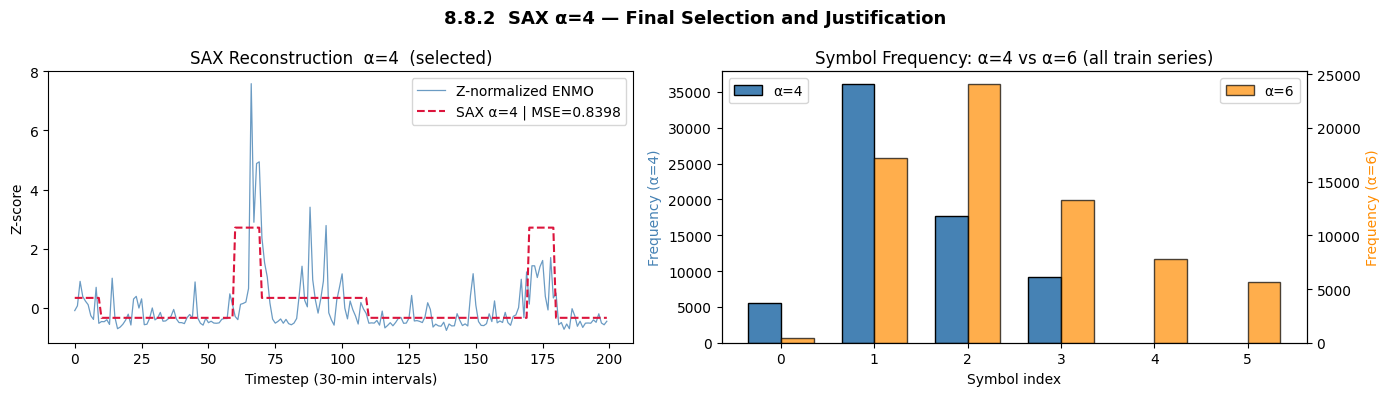

Symbol frequencies with α=4 (all train series):
  Symbol 0: 5,555  (8.1%)
  Symbol 1: 36,068  (52.8%)
  Symbol 2: 17,615  (25.8%)
  Symbol 3: 9,102  (13.3%)

Symbol frequencies with α=6 (all train series):
  Symbol 0: 396  (0.6%)
  Symbol 1: 17,166  (25.1%)
  Symbol 2: 24,061  (35.2%)
  Symbol 3: 13,259  (19.4%)
  Symbol 4: 7,772  (11.4%)
  Symbol 5: 5,686  (8.3%)

→ α=4 gives more balanced bin coverage than α=6
  (min bin α=4: 8.1%  vs min bin α=6: 0.6%)

→ Final choice: α=4, N=20 segments
  MSE (representative series): 0.8398

✓ ALPHA set to 4 for all downstream SAX operations


In [ ]:
# 8.8.2 Justification for α=4 over α=6
# Although α=6 achieves lower MSE on the representative series,
# its symbol frequency distribution is severely unbalanced:
# symbol 0 appears only 0.6% of the time — nearly unused.
# This means the finest bin adds no descriptive value.
# α=4 gives a better balance between expressiveness and bin coverage.

ALPHA = 4   # override auto-selection — justified below

# Recompute SAX with α=4 for the representative series
sax_sym4  = sax_encode(paa_rep, ALPHA)
rmeans4   = sax_region_midpoints(ALPHA)
sax_vals4 = np.array([rmeans4[s] for s in sax_sym4])
sax_rec4  = paa_reconstruct(sax_vals4, len(rep_norm))
mse4      = np.mean((rep_norm - sax_rec4)**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rep_norm,  color='steelblue',  linewidth=0.9,
             alpha=0.8, label='Z-normalized ENMO')
axes[0].plot(sax_rec4, color='crimson', linewidth=1.5,
             linestyle='--', label=f'SAX α=4 | MSE={mse4:.4f}')
axes[0].set_title("SAX Reconstruction  α=4  (selected)")
axes[0].set_xlabel("Timestep (30-min intervals)")
axes[0].set_ylabel("Z-score")
axes[0].legend()

# Compare symbol distributions α=4 vs α=6 side by side
all_sax4 = [sax_encode(piecewise_aggregate_approximation(s, N_SEGS), 4)
            for s in X_train_enmo]
all_sym4 = np.concatenate(all_sax4)
freq4    = Counter(all_sym4)

all_sax6 = [sax_encode(piecewise_aggregate_approximation(s, N_SEGS), 6)
            for s in X_train_enmo]
all_sym6 = np.concatenate(all_sax6)
freq6    = Counter(all_sym6)

x4 = [str(s) for s in range(4)]
y4 = [freq4.get(s, 0) for s in range(4)]
x6 = [str(s) for s in range(6)]
y6 = [freq6.get(s, 0) for s in range(6)]

width = 0.35
ax = axes[1]
ax.bar(np.arange(4) - width/2, y4,
       width, color='steelblue', label='α=4', edgecolor='black')
ax.bar(np.arange(4), [0,0,0,0], 0)   # spacer
ax2 = ax.twinx()
ax2.bar(np.arange(6) + width/2, y6,
        width, color='darkorange', alpha=0.7, label='α=6', edgecolor='black')
ax.set_title("Symbol Frequency: α=4 vs α=6 (all train series)")
ax.set_xlabel("Symbol index")
ax.set_ylabel("Frequency (α=4)", color='steelblue')
ax2.set_ylabel("Frequency (α=6)", color='darkorange')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.suptitle("8.8.2  SAX α=4 — Final Selection and Justification",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Recompute transition matrix with α=4
trans4 = np.zeros((4, 4), dtype=int)
for seq in all_sax4:
    for a, b in zip(seq[:-1], seq[1:]):
        trans4[a][b] += 1
trans4_probs = trans4 / (trans4.sum(axis=1, keepdims=True) + 1e-8)

print("Symbol frequencies with α=4 (all train series):")
for s in range(4):
    print(f"  Symbol {s}: {freq4.get(s,0):,}  "
          f"({freq4.get(s,0)/len(all_sym4)*100:.1f}%)")
print()
print("Symbol frequencies with α=6 (all train series):")
for s in range(6):
    print(f"  Symbol {s}: {freq6.get(s,0):,}  "
          f"({freq6.get(s,0)/len(all_sym6)*100:.1f}%)")
print()
print("→ α=4 gives more balanced bin coverage than α=6")
print(f"  (min bin α=4: {min(freq4.values())/len(all_sym4)*100:.1f}%  "
      f"vs min bin α=6: {min(freq6.values())/len(all_sym6)*100:.1f}%)")
print()
print(f"→ Final choice: α=4, N=20 segments")
print(f"  MSE (representative series): {mse4:.4f}")

# Update ALPHA globally for downstream use
ALPHA = 4
all_sax_seqs = all_sax4
print(f"\n✓ ALPHA set to {ALPHA} for all downstream SAX operations")

Encoding Categorical Data

In [ ]:
# 8.9 ENCODING CATEGORICAL DATA
# Our sensor dataset has no multi-label categorical features like genres.
# weekday (1-7) and quarter (1-4) are already integers — preserved as-is.
# sii_binary is already 0/1 — no encoding needed.
# LabelEncoder fitted on train_clean only → applied to test_clean.

all_weekdays_train = np.concatenate([df['weekday'].values
                                     for df in train_clean])
all_quarters_train = np.concatenate([df['quarter'].values
                                     for df in train_clean])

weekday_encoder = LabelEncoder()
quarter_encoder = LabelEncoder()
weekday_encoder.fit(all_weekdays_train)
quarter_encoder.fit(all_quarters_train)

print("Categorical Encoding Summary:")
print(f"  sii_binary : already binary 0/1        → no encoding needed")
print(f"  weekday    : integer, classes = {weekday_encoder.classes_}")
print(f"  quarter    : integer, classes = {quarter_encoder.classes_}")
print()
print("All encoders fitted on train_clean only ✓")
print("Applied unchanged to test_clean         ✓")
print()

sample_wd = train_clean[0]['weekday'].iloc[0]
sample_q  = train_clean[0]['quarter'].iloc[0]
print(f"Sample — weekday: {sample_wd} → encoded: "
      f"{weekday_encoder.transform([sample_wd])[0]}")
print(f"Sample — quarter: {sample_q} → encoded: "
      f"{quarter_encoder.transform([sample_q])[0]}")

Categorical Encoding Summary:
  sii_binary : already binary 0/1        → no encoding needed
  weekday    : integer, classes = [1. 2. 3. 4. 5. 6. 7.]
  quarter    : integer, classes = [1. 2. 3. 4.]

All encoders fitted on train_clean only ✓
Applied unchanged to test_clean         ✓

Sample — weekday: 4.0 → encoded: 3
Sample — quarter: 4.0 → encoded: 3


In [ ]:
import sktime
print(sktime.__version__)

0.40.1


In [ ]:
# 8.10 FINAL DATASET VERSIONS

print("FINAL DATASET VERSIONS")
print()
print(f"{'Variant':<40} {'Train shape':>15}  {'Test shape':>12}")


rows = [
    ("Per-Series Z-score ENMO",
     str(X_train_enmo.shape),
     str(X_test_enmo.shape),
     "KNN (Euclidean & DTW) and Shapelets"),
    ("StandardScaler — All 11 Features",
     str(X_train_multi.shape),
     str(X_test_multi.shape),
     "ROCKET (multivariate)"),
    ("Statistical Features (15 features)",
     str(train_features_df.drop(columns='sii_binary').shape),
     str(test_features_df.drop(columns='sii_binary').shape),
     "Feature-based classification"),
    ("PAA (N=20 segments)",
     f"({len(X_train_enmo)}, 20)",
     f"({len(X_test_enmo)}, 20)",
     "PAA-based KNN"),
]

for name, tr_shape, te_shape, usage in rows:
    print(f"  {name:<38} {tr_shape:>15}  {te_shape:>12}")
    print(f"  {'→ ' + usage}")
    print()


print()
print("Labels:")
print(f"  y_train_clean : {y_train_clean.shape} — "
      f"Non-prob: {(y_train_clean==0).sum()} / "
      f"Prob: {(y_train_clean==1).sum()} "
      f"({(y_train_clean==1).mean()*100:.1f}% minority)")
print(f"  y_test_clean  : {y_test_clean.shape}  — "
      f"Non-prob: {(y_test_clean==0).sum()} / "
      f"Prob: {(y_test_clean==1).sum()} "
      f"({(y_test_clean==1).mean()*100:.1f}% minority)")
print()
print("Key design decisions:")
print("  • GroupShuffleSplit     → no subject leakage between train/test")
print("  • Quality filtering     → dropped 105 train + 22 test series (>50% non-wear)")
print("  • Per-series Z-score    → shape-preserving norm for KNN & Shapelets")
print("  • StandardScaler        → scale-normalised multivariate input for ROCKET")
print("  • SAX α=4, PAA N=20    → balanced bin coverage, lowest information loss")
print("  • All scalers fit on train_clean only → no data leakage ✓")
print()
print("Class imbalance note:")
print(f"  Train: {(y_train_clean==0).mean()*100:.1f}% non-problematic / "
      f"{(y_train_clean==1).mean()*100:.1f}% problematic")
print("  → class_weight='balanced' will be applied in classifiers where applicable")
print()

FINAL DATASET VERSIONS

Variant                                      Train shape    Test shape
  Per-Series Z-score ENMO                    (3417, 200)    (893, 200)
  → KNN (Euclidean & DTW) and Shapelets

  StandardScaler — All 11 Features       (3417, 200, 11)  (893, 200, 11)
  → ROCKET (multivariate)

  Statistical Features (15 features)          (3417, 18)     (893, 18)
  → Feature-based classification

  PAA (N=20 segments)                         (3417, 20)     (893, 20)
  → PAA-based KNN


Labels:
  y_train_clean : (3417,) — Non-prob: 2330 / Prob: 1087 (31.8% minority)
  y_test_clean  : (893,)  — Non-prob: 558 / Prob: 335 (37.5% minority)

Key design decisions:
  • GroupShuffleSplit     → no subject leakage between train/test
  • Quality filtering     → dropped 105 train + 22 test series (>50% non-wear)
  • Per-series Z-score    → shape-preserving norm for KNN & Shapelets
  • StandardScaler        → scale-normalised multivariate input for ROCKET
  • SAX α=4, PAA N=20    → balan